In [26]:
import numpy as np
import pandas as pd, matplotlib.pyplot as plt
import os

import Project1.A3.utils_a3 as utils

adni_data_rel_path  = os.path.join("resources",
                                   "TEST_NEW",
                                   "structured_files_UCBERKELEY_AMY_6MM_29Oct2025",
                                   "UCBERKELEY_AMY_6MM_29Oct2025_suvr.csv")
params = dict()
query_filter = params.get("query_filter", None)

In [5]:
df = utils.df_rename_to_fsnames(adni_data_rel_path, query_filter=query_filter)
df = utils.safe_filter_df(df, True)
df.sort_values(by=['rid', 'scandate'], inplace=True)
df, feature_cols = utils.activations_cortical_regions_df(df, True)

df.head()

In [6]:
feature_names = [col.removesuffix("_positivity") for col in df.columns if col.endswith("positivity")]

,loniuid,ptid,rid,scandate,qc_flag,tracer,amyloid_status,amyloid_status_composite_ref,centiloids,summary_suvr,...,lh_transversetemporal_positivity,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity
615,1594517,011_S_0021,21,2010-10-08,2,FBP,0.0,0.0,0.0,1.007,...,0,0,1,1,1,1,0,0,0,1
616,1594530,011_S_0021,21,2012-10-03,2,FBP,0.0,0.0,-9.0,0.956,...,0,0,1,0,1,1,0,0,0,1
617,1594602,011_S_0021,21,2015-11-05,2,FBP,0.0,0.0,-11.0,0.948,...,0,0,1,0,1,1,0,0,0,1
618,1594546,011_S_0021,21,2017-11-28,2,FBP,0.0,0.0,2.0,1.016,...,1,0,1,1,1,1,0,0,0,1
619,1594569,011_S_0023,23,2010-12-21,2,FBP,1.0,0.0,21.0,1.115,...,1,0,1,1,1,1,1,1,1,1


In [16]:
regions = [col for col in df.columns if col.endswith("positivity")]
cols_to_keep = ['rid' ,  'summary_suvr']  + regions


df_filtered = df[cols_to_keep].copy()
df_filtered.head()

,rid,summary_suvr,rh_lateralorbitofrontal_positivity,rh_parsorbitalis_positivity,rh_frontalpole_positivity,rh_medialorbitofrontal_positivity,rh_parstriangularis_positivity,rh_parsopercularis_positivity,rh_rostralmiddlefrontal_positivity,rh_superiorfrontal_positivity,...,lh_transversetemporal_positivity,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity
615,21,1.007,1,0,0,0,0,0,0,0,...,0,0,1,1,1,1,0,0,0,1
616,21,0.956,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,1
618,21,1.016,0,0,0,0,0,0,0,0,...,1,0,1,1,1,1,0,0,0,1
617,21,0.948,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,1
620,23,1.117,1,0,0,0,0,1,0,0,...,0,0,1,0,1,1,0,1,0,1


In [17]:
df_ad = df_filtered[df_filtered['rid'].isin(df_filtered[df_filtered['summary_suvr'] > 1.1]['rid'].unique())]
df_ad.head()

,rid,summary_suvr,rh_lateralorbitofrontal_positivity,rh_parsorbitalis_positivity,rh_frontalpole_positivity,rh_medialorbitofrontal_positivity,rh_parstriangularis_positivity,rh_parsopercularis_positivity,rh_rostralmiddlefrontal_positivity,rh_superiorfrontal_positivity,...,lh_transversetemporal_positivity,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity
620,23,1.117,1,0,0,0,0,1,0,0,...,0,0,1,0,1,1,0,1,0,1
619,23,1.115,1,0,0,0,0,0,0,1,...,1,0,1,1,1,1,1,1,1,1
623,31,1.395,1,1,1,1,1,1,1,1,...,1,1,0,0,1,1,1,0,0,1
621,31,1.214,1,1,1,1,1,1,1,1,...,1,1,1,0,1,1,1,0,0,1
624,31,1.518,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,1


### Frequency Analysis of AD positivie Patients

In [24]:

AD_rows = df_ad[df_ad['summary_suvr']>1.1]
per_patient = AD_rows.groupby('rid')[regions].max() # to only get 1 entry per patient (with AD = 1)
# region_probs = df_ad[regions].mean().sort_values(ascending=False)
# high_probability_regions = region_probs[region_probs >= 0.9]
# high_probability_regions

region_probs_per_patient = per_patient.mean().sort_values(ascending=False)
region_probs_per_patient

lh_pallidum_positivity        1.000000
rh_bankssts_positivity        0.997940
lh_bankssts_positivity        0.997940
rh_pallidum_positivity        0.997940
rh_putamen_positivity         0.993821
                                ...   
lh_temporalpole_positivity    0.510814
lh_hippocampus_positivity     0.486097
rh_temporalpole_positivity    0.470649
lh_entorhinal_positivity      0.263646
rh_entorhinal_positivity      0.247168
Length: 83, dtype: float64

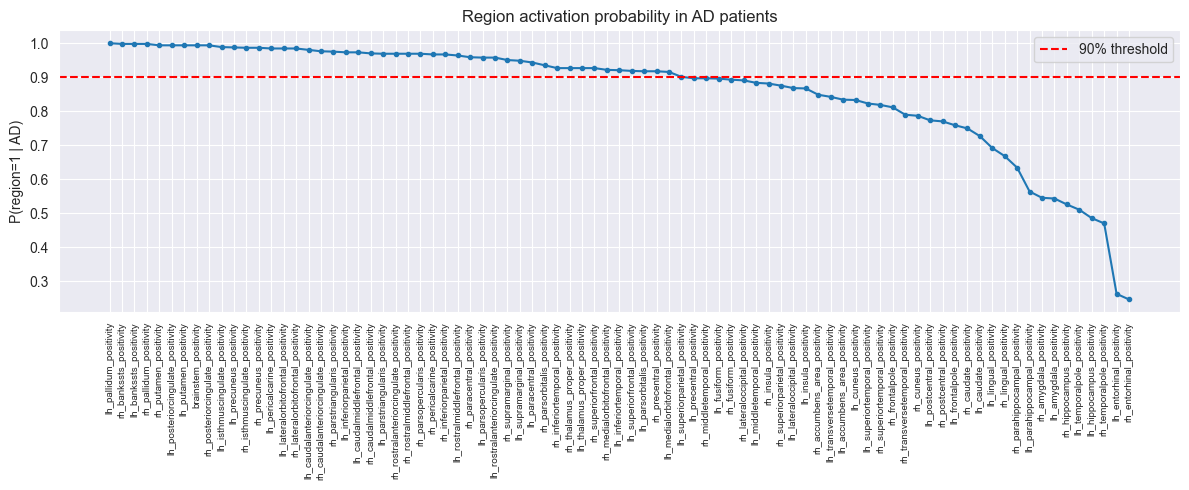

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(range(len(region_probs_per_patient)), region_probs_per_patient.values, marker='o', markersize=3)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% threshold')
plt.xticks(range(len(region_probs_per_patient)), region_probs_per_patient.index, rotation=90, fontsize=7)
plt.ylabel('P(region=1 | AD)')
plt.title('Region activation probability in AD patients')
plt.legend()
plt.tight_layout()
plt.show()

## Correlation on per-patient AD

In [32]:
import seaborn as sns

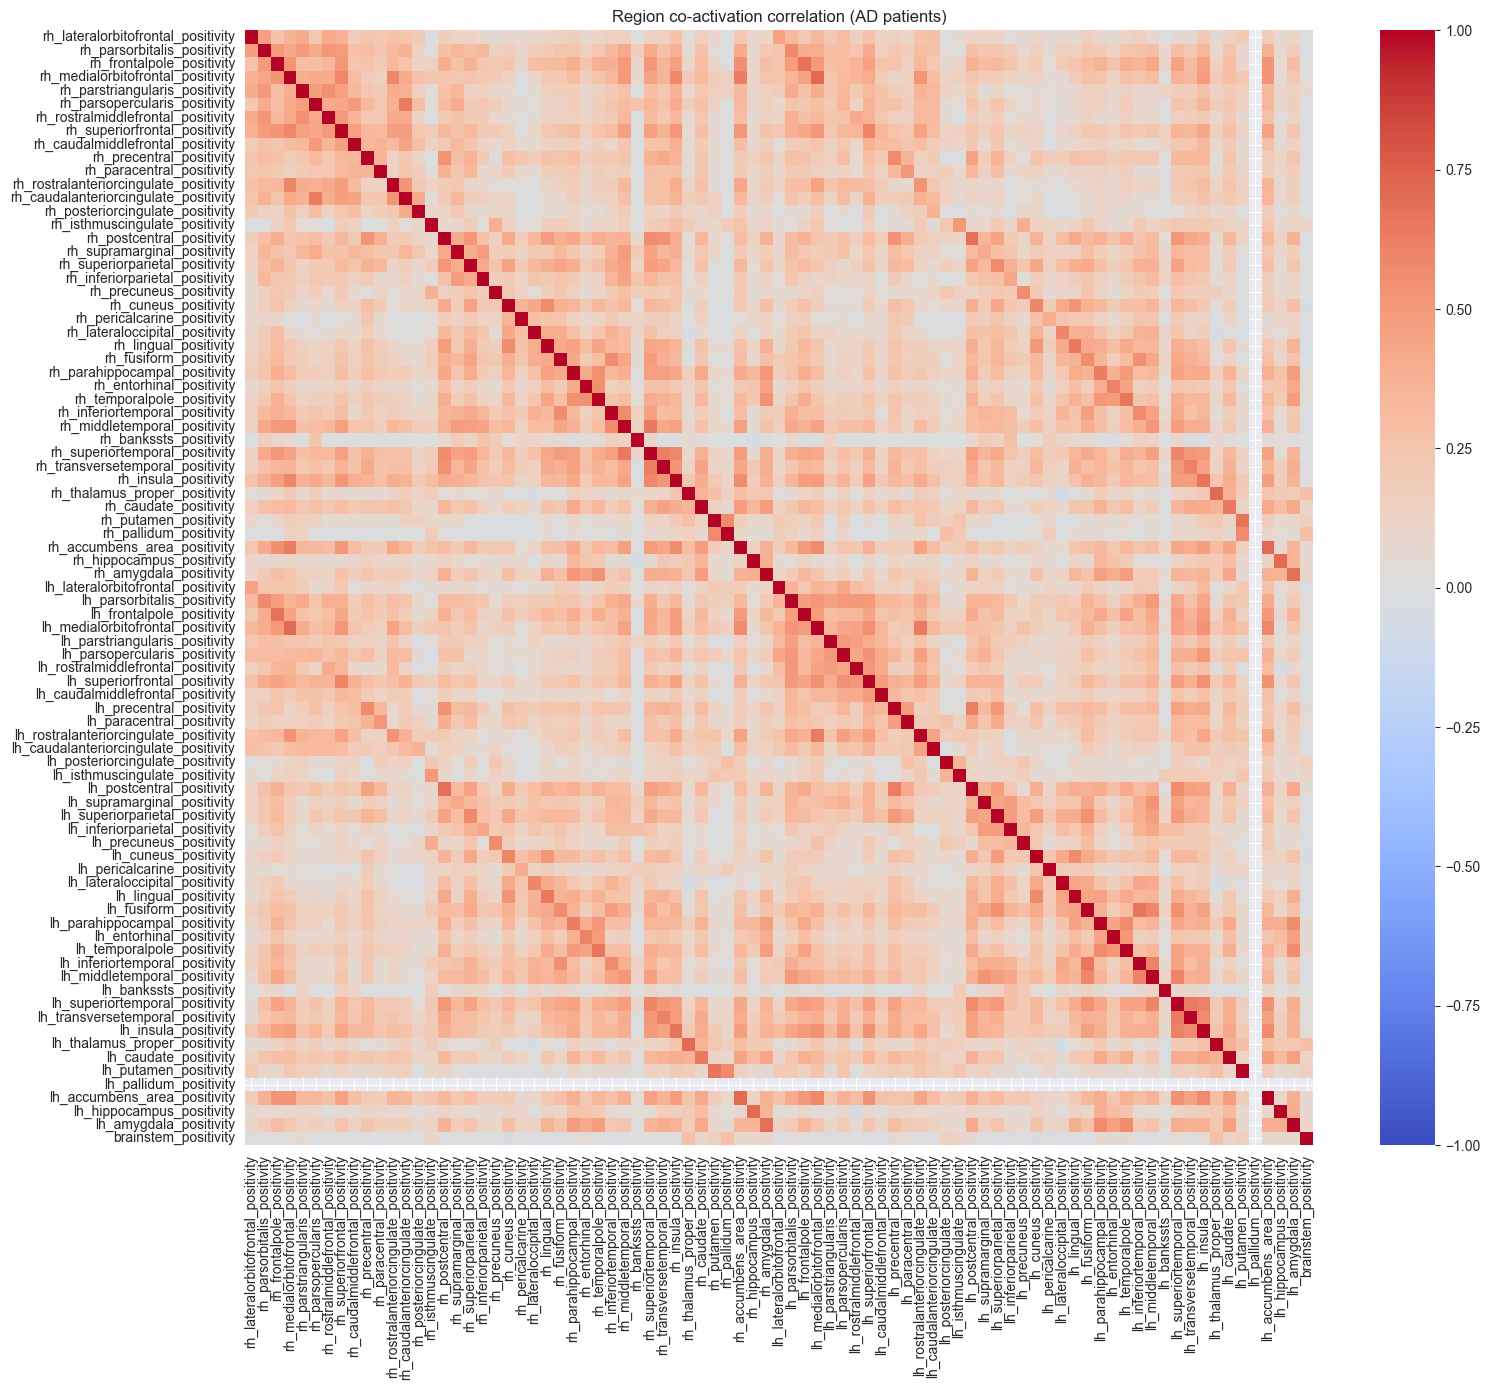

In [33]:
corr = per_patient[regions].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            xticklabels=True,
            yticklabels=True)
plt.title('Region co-activation correlation AD ONLY')
plt.tight_layout()
plt.show()